# Cardiovascular Disease Prediction — Deep Learning Coursework

**Dataset:** `cardio_train.csv` — 70,000 patient records, binary classification (CVD: yes/no)

**Models implemented:**
| # | Model | Lectures covered |
|---|-------|------------------|
| 1 | Logistic Regression (PyTorch) | Lectures 3 & 4 — Binary Classification |
| 2 | MLP / Fully-Connected NN | Lectures 5, 6, 10, 11 — FCNNs + Improving Performance |
| 3 | Autoencoder + Classifier | Lecture 14 — Disease Detection with Autoencoders |

## 0. Imports & Setup

In [19]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.6.0+cu124
Device: GPU


## 1. Data Loading & Preprocessing

In [20]:
df = pd.read_csv("cardio_train.csv", sep=";")
print("Shape:", df.shape)
df.head()

Shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [21]:
print("Class balance:")
print(df["cardio"].value_counts())
print(f"\nCVD positive rate: {df['cardio'].mean():.2%}")
df.describe()

Class balance:
cardio
0    35021
1    34979
Name: count, dtype: int64

CVD positive rate: 49.97%


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
# Convert age from days → years (more interpretable)
df["age"] = df["age"] / 365

# Drop ID column (not a feature)
df = df.drop(columns=["id"])

# Remove obvious outliers in blood pressure
df = df[(df["ap_hi"] >= 80) & (df["ap_hi"] <= 200)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 150)]

print(f"After cleaning: {df.shape}")

# Features and target
X = df.drop(columns=["cardio"]).values
y = df["cardio"].values
feature_names = df.drop(columns=["cardio"]).columns.tolist()
print("Features:", feature_names)

After cleaning: (68687, 12)
Features: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [23]:
# Train / Val / Test split: 70% / 15% / 15%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Standardise features — fit ONLY on training set to avoid data leakage
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Convert to PyTorch tensors
def to_tensors(X, y):
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32))

X_tr, y_tr = to_tensors(X_train, y_train)
X_vl, y_vl = to_tensors(X_val,   y_val)
X_ts, y_ts = to_tensors(X_test,  y_test)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_vl, y_vl), batch_size=256)
test_loader  = DataLoader(TensorDataset(X_ts, y_ts), batch_size=256)

INPUT_DIM = X_train.shape[1]
print(f"Input features : {INPUT_DIM}")
print(f"Train samples  : {len(X_tr)}")
print(f"Val samples    : {len(X_vl)}")
print(f"Test samples   : {len(X_ts)}")

Input features : 11
Train samples  : 48080
Val samples    : 10303
Test samples   : 10304


## 2. Helper Functions (Training Loop & Evaluation)

In [24]:
def train_model(model, train_loader, val_loader, optimizer, criterion,
                epochs=30, model_name="Model"):
    """Generic training loop for binary classification models."""
    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(1, epochs + 1):
        # ── Training phase ──
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch).squeeze()
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # ── Validation phase ──
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                preds     = model(X_batch).squeeze()
                val_loss += criterion(preds, y_batch).item()
                predicted = (preds >= 0.5).float()
                correct  += (predicted == y_batch).sum().item()
                total    += y_batch.size(0)

        train_losses.append(epoch_loss / len(train_loader))
        val_losses.append(val_loss   / len(val_loader))
        val_accs.append(correct / total)

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:3d}/{epochs} | "
                  f"Train Loss: {train_losses[-1]:.4f} | "
                  f"Val Loss: {val_losses[-1]:.4f} | "
                  f"Val Acc: {val_accs[-1]:.4f}")

    return train_losses, val_losses, val_accs


def evaluate_model(model, test_loader, model_name="Model", is_autoencoder=False):
    """Evaluate model on test set and print classification report.
    Set is_autoencoder=True for models that return (cvd_prob, x_recon) tuples.
    """
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model(X_batch)
            # Autoencoder returns a tuple (cvd_prob, x_recon) — extract just the prob
            probs = output[0].squeeze() if is_autoencoder else output.squeeze()
            preds = (probs >= 0.5).float()
            all_probs.extend(probs.numpy())
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())

    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    print(f"\n{'='*55}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(classification_report(all_labels, all_preds,
                                 target_names=["No CVD", "CVD"]))
    return acc, auc


def plot_curves(name, train_losses, val_losses, val_accs):
    """Plot training/validation loss and validation accuracy."""
    epochs_range = range(1, len(train_losses) + 1)
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax2 = ax1.twinx()
    ax1.plot(epochs_range, train_losses, label="Train Loss", color="steelblue")
    ax1.plot(epochs_range, val_losses,   label="Val Loss",   color="tomato", linestyle="--")
    ax2.plot(epochs_range, val_accs,     label="Val Acc",    color="seagreen", linestyle=":")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax2.set_ylabel("Accuracy")
    ax1.set_title(f"{name} — Training Curves")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
    plt.tight_layout()
    plt.show()

## 3. Model 1 — Logistic Regression *(Lectures 3 & 4)*

The simplest binary classifier: a single `nn.Linear` layer followed by a **sigmoid** activation.

- Input: 11 patient features
- Output: probability of CVD (0–1)
- Loss: Binary Cross-Entropy (BCE)
- The learned **weights** directly show which features increase/decrease CVD risk

In [25]:
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


lr_model = LogisticRegressionModel(INPUT_DIM)
lr_optim = torch.optim.Adam(lr_model.parameters(), lr=0.0005, weight_decay=1e-3)
lr_crit  = nn.BCELoss()

lr_train_losses, lr_val_losses, lr_val_accs = train_model(
    lr_model, train_loader, val_loader, lr_optim, lr_crit,
    epochs=50, model_name="LogReg"
)


print(lr_model)
print(f"\nTotal parameters: {sum(p.numel() for p in lr_model.parameters())}")

[LogReg] Epoch   1/50 | Train Loss: 0.6758 | Val Loss: 0.6512 | Val Acc: 0.6219
[LogReg] Epoch   5/50 | Train Loss: 0.5837 | Val Loss: 0.5813 | Val Acc: 0.7077
[LogReg] Epoch  10/50 | Train Loss: 0.5665 | Val Loss: 0.5680 | Val Acc: 0.7212
[LogReg] Epoch  15/50 | Train Loss: 0.5621 | Val Loss: 0.5645 | Val Acc: 0.7245
[LogReg] Epoch  20/50 | Train Loss: 0.5604 | Val Loss: 0.5633 | Val Acc: 0.7268
[LogReg] Epoch  25/50 | Train Loss: 0.5598 | Val Loss: 0.5630 | Val Acc: 0.7260
[LogReg] Epoch  30/50 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7266
[LogReg] Epoch  35/50 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7262
[LogReg] Epoch  40/50 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7269
[LogReg] Epoch  45/50 | Train Loss: 0.5596 | Val Loss: 0.5629 | Val Acc: 0.7265
[LogReg] Epoch  50/50 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7267
LogisticRegressionModel(
  (linear): Linear(in_features=11, out_features=1, bias=True)
)

Total parameters: 12


In [26]:
lr_train_losses, lr_val_losses, lr_val_accs = train_model(
    lr_model, train_loader, val_loader, lr_optim, lr_crit,
    epochs=30, model_name="LogReg"
)

[LogReg] Epoch   1/30 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7265
[LogReg] Epoch   5/30 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7267
[LogReg] Epoch  10/30 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7262
[LogReg] Epoch  15/30 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7262
[LogReg] Epoch  20/30 | Train Loss: 0.5597 | Val Loss: 0.5629 | Val Acc: 0.7266
[LogReg] Epoch  25/30 | Train Loss: 0.5597 | Val Loss: 0.5628 | Val Acc: 0.7263
[LogReg] Epoch  30/30 | Train Loss: 0.5596 | Val Loss: 0.5629 | Val Acc: 0.7264



  Logistic Regression — Test Results
  Accuracy : 0.7235
  ROC-AUC  : 0.7887
              precision    recall  f1-score   support

      No CVD       0.70      0.79      0.74      5155
         CVD       0.76      0.66      0.70      5149

    accuracy                           0.72     10304
   macro avg       0.73      0.72      0.72     10304
weighted avg       0.73      0.72      0.72     10304



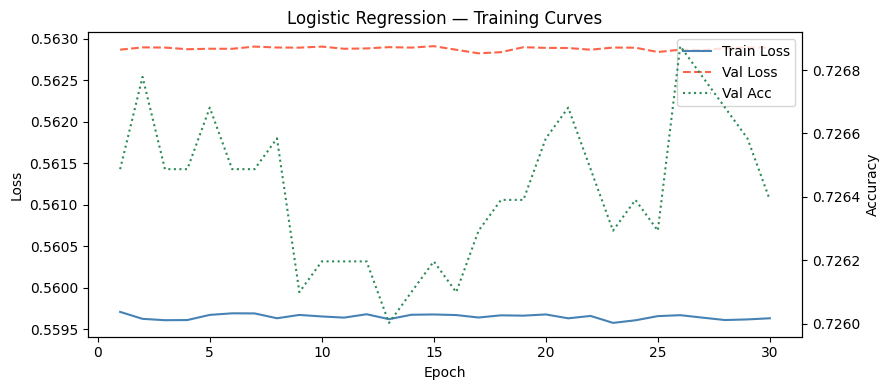

In [27]:
lr_acc, lr_auc = evaluate_model(lr_model, test_loader, "Logistic Regression")
plot_curves("Logistic Regression", lr_train_losses, lr_val_losses, lr_val_accs)

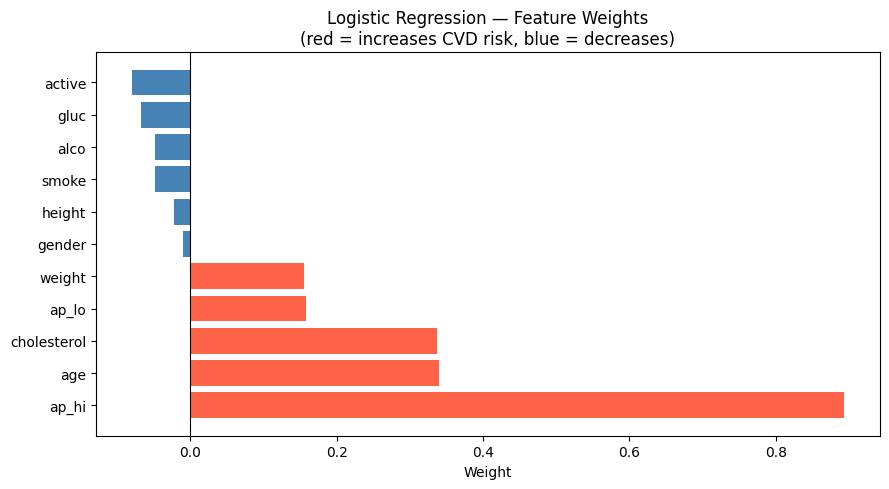


Feature weights (sorted by magnitude):
  ap_hi          : +0.8938
  age            : +0.3403
  cholesterol    : +0.3368
  ap_lo          : +0.1582
  weight         : +0.1550
  active         : -0.0802
  gluc           : -0.0673
  alco           : -0.0479
  smoke          : -0.0476
  height         : -0.0218
  gender         : -0.0097


In [28]:
# Inspect learned feature weights
weights = lr_model.linear.weight.data.squeeze().numpy()
sorted_feats = sorted(zip(feature_names, weights), key=lambda x: x[1], reverse=True)

names_sorted = [f[0] for f in sorted_feats]
weights_sorted = [f[1] for f in sorted_feats]
colors = ["tomato" if w > 0 else "steelblue" for w in weights_sorted]

plt.figure(figsize=(9, 5))
plt.barh(names_sorted, weights_sorted, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Weight")
plt.title("Logistic Regression — Feature Weights\n(red = increases CVD risk, blue = decreases)")
plt.tight_layout()
plt.show()

print("\nFeature weights (sorted by magnitude):")
for name, w in sorted(zip(feature_names, weights), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:15s}: {w:+.4f}")

## 4. Model 2 — Fully-Connected Neural Network (MLP) *(Lectures 5, 6, 10, 11)*

A multi-layer perceptron with performance improvements from lectures:

- **BatchNorm** after each linear layer (Lecture 10)
- **Dropout** regularisation (Lecture 10)
- **StepLR** learning rate scheduler (Lecture 11)
- **Weight decay** (L2 regularisation) in the Adam optimiser

Architecture: `11 → 128 → 64 → 32 → 1`

In [29]:
# Wider network, more epochs, lower dropout, cosine LR schedule
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64, 32], dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

mlp_model = MLP(INPUT_DIM)
mlp_optim = torch.optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
mlp_crit  = nn.BCELoss()

# Cosine annealing — smoother LR decay than StepLR
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(mlp_optim, T_max=60)

mlp_train_losses, mlp_val_losses, mlp_val_accs = [], [], []

for epoch in range(1, 61):  # 60 epochs
    mlp_model.train()
    ep_loss = 0
    for X_batch, y_batch in train_loader:
        mlp_optim.zero_grad()
        loss = mlp_crit(mlp_model(X_batch).squeeze(), y_batch)
        loss.backward()
        mlp_optim.step()
        ep_loss += loss.item()
    scheduler.step()

    mlp_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds     = mlp_model(X_batch).squeeze()
            val_loss += mlp_crit(preds, y_batch).item()
            correct  += ((preds >= 0.5).float() == y_batch).sum().item()
            total    += y_batch.size(0)

    mlp_train_losses.append(ep_loss / len(train_loader))
    mlp_val_losses.append(val_loss / len(val_loader))
    mlp_val_accs.append(correct / total)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[MLP] Epoch {epoch:3d}/60 | Train Loss: {mlp_train_losses[-1]:.4f} | "
              f"Val Loss: {mlp_val_losses[-1]:.4f} | Val Acc: {mlp_val_accs[-1]:.4f}")

print(mlp_model)
print(f"\nTotal parameters: {sum(p.numel() for p in mlp_model.parameters())}")

[MLP] Epoch   1/60 | Train Loss: 0.5663 | Val Loss: 0.5497 | Val Acc: 0.7325
[MLP] Epoch  10/60 | Train Loss: 0.5451 | Val Loss: 0.5463 | Val Acc: 0.7344
[MLP] Epoch  20/60 | Train Loss: 0.5421 | Val Loss: 0.5475 | Val Acc: 0.7325
[MLP] Epoch  30/60 | Train Loss: 0.5389 | Val Loss: 0.5485 | Val Acc: 0.7313
[MLP] Epoch  40/60 | Train Loss: 0.5365 | Val Loss: 0.5481 | Val Acc: 0.7323
[MLP] Epoch  50/60 | Train Loss: 0.5337 | Val Loss: 0.5480 | Val Acc: 0.7335
[MLP] Epoch  60/60 | Train Loss: 0.5341 | Val Loss: 0.5481 | Val Acc: 0.7348
MLP(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in

In [30]:
mlp_train_losses, mlp_val_losses, mlp_val_accs = [], [], []

for epoch in range(1, 31):
    mlp_model.train()
    ep_loss = 0
    for X_batch, y_batch in train_loader:
        mlp_optim.zero_grad()
        loss = mlp_crit(mlp_model(X_batch).squeeze(), y_batch)
        loss.backward()
        mlp_optim.step()
        ep_loss += loss.item()
    scheduler.step()  # Update learning rate

    mlp_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            preds     = mlp_model(X_batch).squeeze()
            val_loss += mlp_crit(preds, y_batch).item()
            correct  += ((preds >= 0.5).float() == y_batch).sum().item()
            total    += y_batch.size(0)

    mlp_train_losses.append(ep_loss / len(train_loader))
    mlp_val_losses.append(val_loss / len(val_loader))
    mlp_val_accs.append(correct / total)

    if epoch % 5 == 0 or epoch == 1:
        current_lr = scheduler.get_last_lr()[0]
        print(f"[MLP] Epoch {epoch:3d}/30 | Train Loss: {mlp_train_losses[-1]:.4f} | "
              f"Val Loss: {mlp_val_losses[-1]:.4f} | Val Acc: {mlp_val_accs[-1]:.4f} | LR: {current_lr:.5f}")

[MLP] Epoch   1/30 | Train Loss: 0.5335 | Val Loss: 0.5483 | Val Acc: 0.7342 | LR: 0.00000
[MLP] Epoch   5/30 | Train Loss: 0.5341 | Val Loss: 0.5485 | Val Acc: 0.7348 | LR: 0.00002
[MLP] Epoch  10/30 | Train Loss: 0.5341 | Val Loss: 0.5483 | Val Acc: 0.7334 | LR: 0.00007
[MLP] Epoch  15/30 | Train Loss: 0.5334 | Val Loss: 0.5488 | Val Acc: 0.7343 | LR: 0.00015
[MLP] Epoch  20/30 | Train Loss: 0.5335 | Val Loss: 0.5503 | Val Acc: 0.7340 | LR: 0.00025
[MLP] Epoch  25/30 | Train Loss: 0.5352 | Val Loss: 0.5485 | Val Acc: 0.7328 | LR: 0.00037
[MLP] Epoch  30/30 | Train Loss: 0.5362 | Val Loss: 0.5486 | Val Acc: 0.7319 | LR: 0.00050



  MLP — Test Results
  Accuracy : 0.7315
  ROC-AUC  : 0.7989
              precision    recall  f1-score   support

      No CVD       0.72      0.76      0.74      5155
         CVD       0.75      0.70      0.72      5149

    accuracy                           0.73     10304
   macro avg       0.73      0.73      0.73     10304
weighted avg       0.73      0.73      0.73     10304



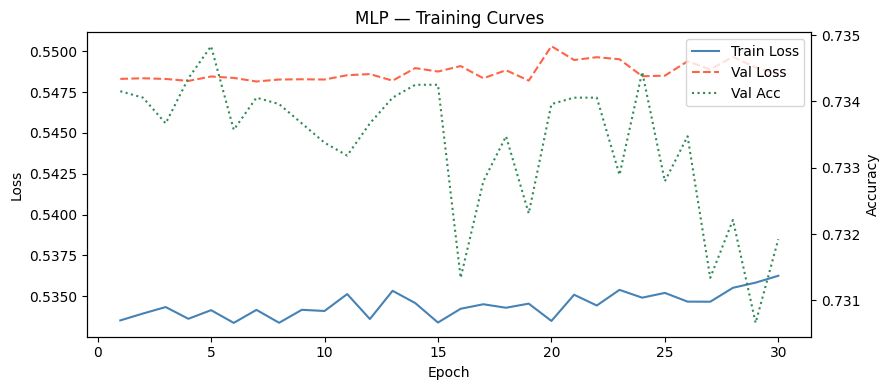

In [31]:
mlp_acc, mlp_auc = evaluate_model(mlp_model, test_loader, "MLP")
plot_curves("MLP", mlp_train_losses, mlp_val_losses, mlp_val_accs)

## 5. Model 3 — Autoencoder *(Lecture 14 — Disease Detection)*

Directly inspired by Lecture 14 (Fraud Detection using Autoencoders), applied here to cardiovascular disease.

**Architecture:**
```
Input (11) → Encoder → Latent Space (8) → Decoder → Reconstructed Input (11)
                              ↓
                        Classifier Head → CVD Probability
```

**Combined loss:**
```
Total Loss = BCE(classification) + 0.5 × MSE(reconstruction)
```

The model learns to both classify CVD **and** reconstruct the input — the latent space captures meaningful compressed representations of patient health.

In [32]:
# Larger latent space, deeper encoder/decoder, more epochs
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, latent_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
        )
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        z        = self.encoder(x)
        x_recon  = self.decoder(z)
        cvd_prob = self.classifier(z)
        return cvd_prob, x_recon


ae_model = Autoencoder(INPUT_DIM, latent_dim=16)
ae_optim = torch.optim.Adam(ae_model.parameters(), lr=0.001, weight_decay=1e-4)
bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()
ae_sched = torch.optim.lr_scheduler.CosineAnnealingLR(ae_optim, T_max=60)

ae_train_losses, ae_val_losses, ae_val_accs = [], [], []

for epoch in range(1, 61):  # 60 epochs
    ae_model.train()
    ep_loss = 0
    for X_batch, y_batch in train_loader:
        ae_optim.zero_grad()
        cvd_prob, x_recon = ae_model(X_batch)
        cls_loss   = bce_loss(cvd_prob.squeeze(), y_batch)
        recon_loss = mse_loss(x_recon, X_batch)
        loss       = cls_loss + 0.3 * recon_loss  # reduced recon weight
        loss.backward()
        ae_optim.step()
        ep_loss += loss.item()
    ae_sched.step()

    ae_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            cvd_prob, x_recon = ae_model(X_batch)
            cls_l    = bce_loss(cvd_prob.squeeze(), y_batch)
            rec_l    = mse_loss(x_recon, X_batch)
            val_loss += (cls_l + 0.3 * rec_l).item()
            preds    = (cvd_prob.squeeze() >= 0.5).float()
            correct  += (preds == y_batch).sum().item()
            total    += y_batch.size(0)

    ae_train_losses.append(ep_loss / len(train_loader))
    ae_val_losses.append(val_loss / len(val_loader))
    ae_val_accs.append(correct / total)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[AE]  Epoch {epoch:3d}/60 | Train Loss: {ae_train_losses[-1]:.4f} | "
              f"Val Loss: {ae_val_losses[-1]:.4f} | Val Acc: {ae_val_accs[-1]:.4f}")

print(ae_model)
print(f"\nTotal parameters: {sum(p.numel() for p in ae_model.parameters())}")

[AE]  Epoch   1/60 | Train Loss: 0.7514 | Val Loss: 0.6350 | Val Acc: 0.7264
[AE]  Epoch  10/60 | Train Loss: 0.5538 | Val Loss: 0.5531 | Val Acc: 0.7321
[AE]  Epoch  20/60 | Train Loss: 0.5485 | Val Loss: 0.5507 | Val Acc: 0.7330
[AE]  Epoch  30/60 | Train Loss: 0.5447 | Val Loss: 0.5511 | Val Acc: 0.7304
[AE]  Epoch  40/60 | Train Loss: 0.5421 | Val Loss: 0.5496 | Val Acc: 0.7318
[AE]  Epoch  50/60 | Train Loss: 0.5401 | Val Loss: 0.5497 | Val Acc: 0.7331
[AE]  Epoch  60/60 | Train Loss: 0.5394 | Val Loss: 0.5498 | Val Acc: 0.7325
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
  )
  (decoder): 

In [33]:
ae_train_losses, ae_val_losses, ae_val_accs = [], [], []

for epoch in range(1, 31):
    ae_model.train()
    ep_loss = 0
    for X_batch, y_batch in train_loader:
        ae_optim.zero_grad()
        cvd_prob, x_recon = ae_model(X_batch)

        # Combined loss: classification + reconstruction
        cls_loss   = bce_loss(cvd_prob.squeeze(), y_batch)
        recon_loss = mse_loss(x_recon, X_batch)
        loss       = cls_loss + 0.5 * recon_loss  # weighted combination

        loss.backward()
        ae_optim.step()
        ep_loss += loss.item()

    ae_model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            cvd_prob, x_recon = ae_model(X_batch)
            cls_l    = bce_loss(cvd_prob.squeeze(), y_batch)
            rec_l    = mse_loss(x_recon, X_batch)
            val_loss += (cls_l + 0.5 * rec_l).item()
            preds    = (cvd_prob.squeeze() >= 0.5).float()
            correct  += (preds == y_batch).sum().item()
            total    += y_batch.size(0)

    ae_train_losses.append(ep_loss / len(train_loader))
    ae_val_losses.append(val_loss / len(val_loader))
    ae_val_accs.append(correct / total)

    if epoch % 5 == 0 or epoch == 1:
        print(f"[AE]  Epoch {epoch:3d}/30 | Train Loss: {ae_train_losses[-1]:.4f} | "
              f"Val Loss: {ae_val_losses[-1]:.4f} | Val Acc: {ae_val_accs[-1]:.4f}")

[AE]  Epoch   1/30 | Train Loss: 0.5431 | Val Loss: 0.5513 | Val Acc: 0.7326
[AE]  Epoch   5/30 | Train Loss: 0.5417 | Val Loss: 0.5512 | Val Acc: 0.7323
[AE]  Epoch  10/30 | Train Loss: 0.5420 | Val Loss: 0.5511 | Val Acc: 0.7324
[AE]  Epoch  15/30 | Train Loss: 0.5419 | Val Loss: 0.5510 | Val Acc: 0.7335
[AE]  Epoch  20/30 | Train Loss: 0.5415 | Val Loss: 0.5510 | Val Acc: 0.7332
[AE]  Epoch  25/30 | Train Loss: 0.5425 | Val Loss: 0.5511 | Val Acc: 0.7320
[AE]  Epoch  30/30 | Train Loss: 0.5418 | Val Loss: 0.5511 | Val Acc: 0.7329



  Autoencoder — Test Results
  Accuracy : 0.7342
  ROC-AUC  : 0.8013
              precision    recall  f1-score   support

      No CVD       0.71      0.78      0.75      5155
         CVD       0.76      0.69      0.72      5149

    accuracy                           0.73     10304
   macro avg       0.74      0.73      0.73     10304
weighted avg       0.74      0.73      0.73     10304



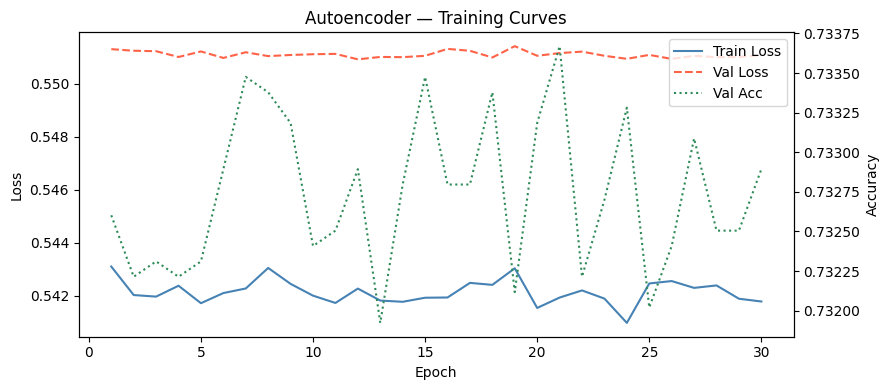

In [34]:
ae_acc, ae_auc = evaluate_model(ae_model, test_loader, "Autoencoder", is_autoencoder=True)
plot_curves("Autoencoder", ae_train_losses, ae_val_losses, ae_val_accs)

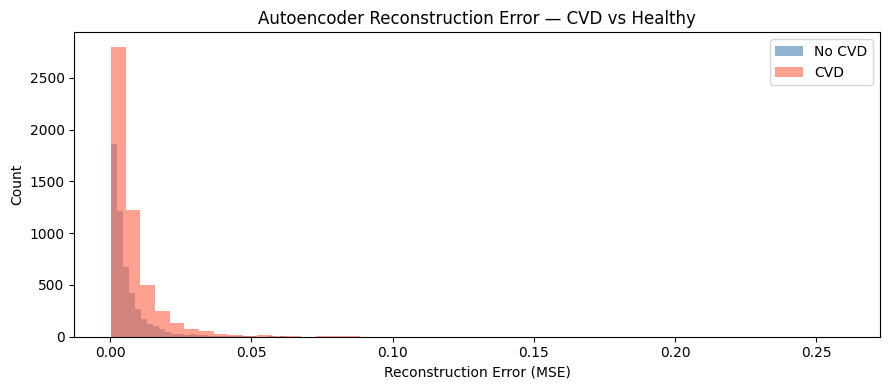

Mean recon error — Healthy: 0.0062
Mean recon error — CVD:     0.0083


In [35]:
# Visualise reconstruction error: CVD patients vs healthy
ae_model.eval()
recon_errors_cvd, recon_errors_healthy = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        _, x_recon = ae_model(X_batch)
        errors = ((x_recon - X_batch) ** 2).mean(dim=1).numpy()
        for err, label in zip(errors, y_batch.numpy()):
            if label == 1:
                recon_errors_cvd.append(err)
            else:
                recon_errors_healthy.append(err)

plt.figure(figsize=(9, 4))
plt.hist(recon_errors_healthy, bins=50, alpha=0.6, label="No CVD",  color="steelblue")
plt.hist(recon_errors_cvd,     bins=50, alpha=0.6, label="CVD",     color="tomato")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("Autoencoder Reconstruction Error — CVD vs Healthy")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean recon error — Healthy: {np.mean(recon_errors_healthy):.4f}")
print(f"Mean recon error — CVD:     {np.mean(recon_errors_cvd):.4f}")

## 6. Model Comparison

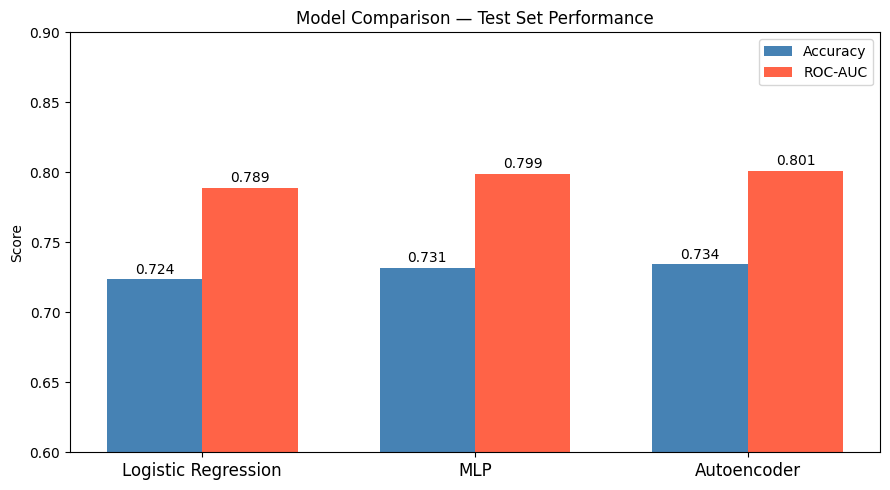


Summary Table:
Model                       Accuracy    ROC-AUC
-----------------------------------------------
Logistic Regression           0.7235     0.7887
MLP                           0.7315     0.7989
Autoencoder                   0.7342     0.8013


In [36]:
model_names = ["Logistic Regression", "MLP", "Autoencoder"]
accuracies  = [lr_acc, mlp_acc, ae_acc]
aucs        = [lr_auc, mlp_auc, ae_auc]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(model_names))
w = 0.35

bars1 = ax.bar(x - w/2, accuracies, w, label="Accuracy", color="steelblue")
bars2 = ax.bar(x + w/2, aucs,       w, label="ROC-AUC",  color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0.6, 0.9)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Test Set Performance")
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

print("\nSummary Table:")
print(f"{'Model':<25} {'Accuracy':>10} {'ROC-AUC':>10}")
print("-" * 47)
for name, acc, auc in zip(model_names, accuracies, aucs):
    print(f"{name:<25} {acc:>10.4f} {auc:>10.4f}")